In [2]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

Este codigo va a comparar las performance de las BDT para el mag up y mag down 

In [3]:
data24_magup = pd.read_pickle('data24_magup_200_all.pkl')

model = CatBoostClassifier().load_model("BDT_MagUP_all")
prob = model.predict_proba(data24_magup)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
data24_magup['prob'] = signal_MVA_probs


[[9.99733558e-01 2.66441780e-04]
 [9.95360646e-01 4.63935423e-03]
 [9.99999122e-01 8.78405599e-07]
 ...
 [1.00000000e+00 6.19477873e-20]
 [1.00000000e+00 2.70203724e-11]
 [9.99999758e-01 2.42344436e-07]]


/tmp/javeser/ipykernel_23398/1200111621.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data24_magup['prob'] = signal_MVA_probs


In [4]:
data24_magdown = pd.read_pickle('data24_magdown_50_all.pkl')

model = CatBoostClassifier().load_model("BDT_MagDown_all")
prob = model.predict_proba(data24_magdown)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
data24_magdown['prob'] = signal_MVA_probs


[[9.99269371e-01 7.30628559e-04]
 [9.99996580e-01 3.41988759e-06]
 [9.99999994e-01 5.68766449e-09]
 ...
 [1.00000000e+00 8.43273934e-12]
 [9.99999931e-01 6.90486899e-08]
 [9.99999820e-01 1.80027959e-07]]


In [10]:
# data24_d = pd.read_pickle('data24_magdown_50_all.pkl')
# data24_u = pd.read_pickle('data24_magup_200_all.pkl')

# data24 = pd.merge(data24_d,data24_u, how= 'outer')


# # model = CatBoostClassifier().load_model("BDT_MagDown_all_test")
# model = CatBoostClassifier().load_model("BDT_MagDown_all_test_IP_noDOCA")
# prob = model.predict_proba(data24)
# print(prob)

# model2 = CatBoostClassifier().load_model("BDT_MagDown_NO_DOCA")
# prob2 = model2.predict_proba(data24)
# print(prob2)

# test = pd.DataFrame()

# signal_MVA_prob_eval = prob
# signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
# data24['prob'] = signal_MVA_probs

# signal_MVA_prob_eval = prob2
# signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
# test['prob_test'] = signal_MVA_probs
# test['Lb_MASS'] = data24['Lb_MASS']


In [11]:
# # data24_magdown = pd.read_pickle('data24_magdown_50_all.pkl')

# # model = CatBoostClassifier().load_model("new_BDT_full_range_2")
# model = CatBoostClassifier().load_model("BDT_MagDown_NO_DOCA")
# prob = model.predict_proba(data24)
# print(prob)

# test = pd.DataFrame()

# signal_MVA_prob_eval = prob
# signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
# test['prob_test'] = signal_MVA_probs
# test['Lb_MASS'] = data24['Lb_MASS']

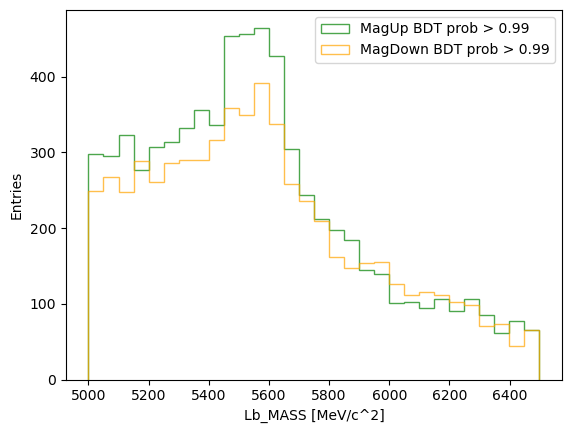

In [7]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = 30

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup.query('(prob > 0.99)')['Lb_MASS'], bins=binning, label='MagUp BDT prob > 0.99', color='green', alpha=0.7, histtype='step')
hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.99)')['Lb_MASS'], bins=binning, label='MagDown BDT prob > 0.99', color='orange', alpha=0.7, histtype='step')

# hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.98) & (L_MASS <1300)')['Lb_MASS'], bins=binning, label='MagDown BDT cut', color='green', alpha=0.7, histtype='step')

# # Calculate the bin centers for the error bars
# bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
# bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# # Plot error bars for the first histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='Binary Data',
#     drawstyle='steps-mid'
# )

# Plot error bars for the second histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )
# axes.errorbar(
#     bin_centers2,
#     hist2,
#     yerr=np.sqrt(hist2),
#     fmt='o',
#     color='orange',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


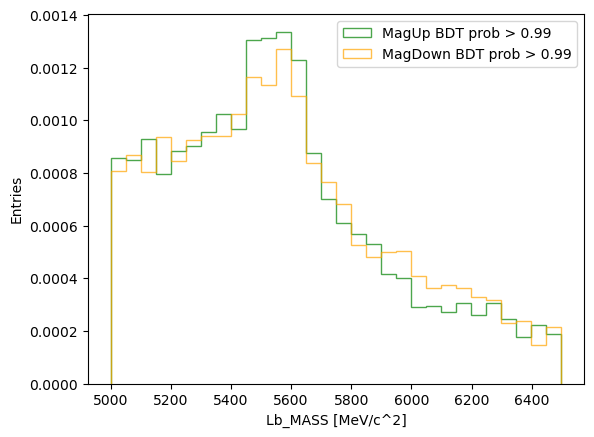

In [6]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = 30
density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup.query('(prob > 0.99)')['Lb_MASS'], bins=binning, label='MagUp BDT prob > 0.99', color='green', alpha=0.7, histtype='step', density= density)
hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.99)')['Lb_MASS'], bins=binning, label='MagDown BDT prob > 0.99', color='orange', alpha=0.7, histtype='step',density= density)

# hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.98) & (L_MASS <1300)')['Lb_MASS'], bins=binning, label='MagDown BDT cut', color='green', alpha=0.7, histtype='step')

# # Calculate the bin centers for the error bars
# bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
# bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# # Plot error bars for the first histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='Binary Data',
#     drawstyle='steps-mid'
# )

# Plot error bars for the second histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )
# axes.errorbar(
#     bin_centers2,
#     hist2,
#     yerr=np.sqrt(hist2),
#     fmt='o',
#     color='orange',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


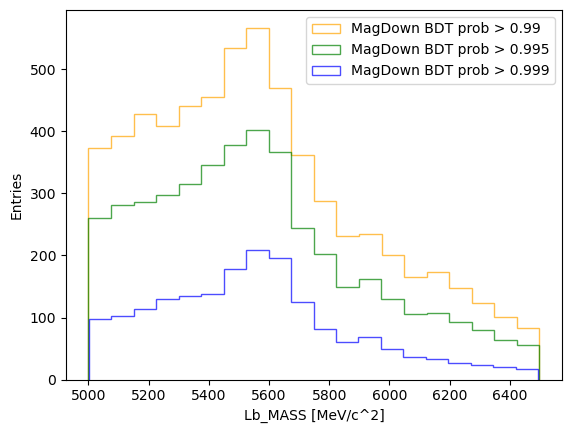

In [7]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = 20

# Plot histograms
# hist1, bins1, _ = axes.hist(data24_magdown.query('(prob_test > 0.99)')['Lb_MASS'], bins=binning, label='Last BDT', color='green', alpha=0.7, histtype='step')
hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.99)')['Lb_MASS'], bins=binning, label='MagDown BDT prob > 0.99', color='orange', alpha=0.7, histtype='step')
hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.995)')['Lb_MASS'], bins=binning, label='MagDown BDT prob > 0.995', color='green', alpha=0.7, histtype='step')
hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.999)')['Lb_MASS'], bins=binning, label='MagDown BDT prob > 0.999', color='blue', alpha=0.7, histtype='step')
# hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.98) & (L_MASS <1300)')['Lb_MASS'], bins=binning, label='MagDown BDT cut', color='green', alpha=0.7, histtype='step')

# # Calculate the bin centers for the error bars
# bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
# bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# # Plot error bars for the first histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='Binary Data',
#     drawstyle='steps-mid'
# )

# Plot error bars for the second histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )
# axes.errorbar(
#     bin_centers2,
#     hist2,
#     yerr=np.sqrt(hist2),
#     fmt='o',
#     color='orange',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


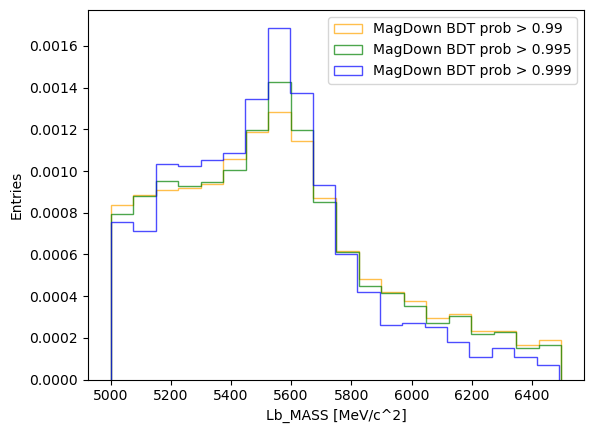

In [24]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = 20
density = True

# Plot histograms
# hist1, bins1, _ = axes.hist(data24_magdown.query('(prob_test > 0.99)')['Lb_MASS'], bins=binning, label='MagUp BDT', color='green', alpha=0.7, histtype='step',density= density)
# hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.99)')['Lb_MASS'], bins=binning, label='MagDown BDT', color='orange', alpha=0.7, histtype='step', density= density)
hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.99)')['Lb_MASS'], bins=binning, label='MagDown BDT prob > 0.99', color='orange', alpha=0.7, histtype='step', density= density)
hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.995)')['Lb_MASS'], bins=binning, label='MagDown BDT prob > 0.995', color='green', alpha=0.7, histtype='step', density= density)
hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.999)')['Lb_MASS'], bins=binning, label='MagDown BDT prob > 0.999', color='blue', alpha=0.7, histtype='step', density= density)
# hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.98) & (L_MASS <1300)')['Lb_MASS'], bins=binning, label='MagDown BDT cut', color='green', alpha=0.7, histtype='step', density= density)

# # Calculate the bin centers for the error bars
# bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
# bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# # Plot error bars for the first histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='Binary Data',
#     drawstyle='steps-mid'
# )

# Plot error bars for the second histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )
# axes.errorbar(
#     bin_centers2,
#     hist2,
#     yerr=np.sqrt(hist2),
#     fmt='o',
#     color='orange',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


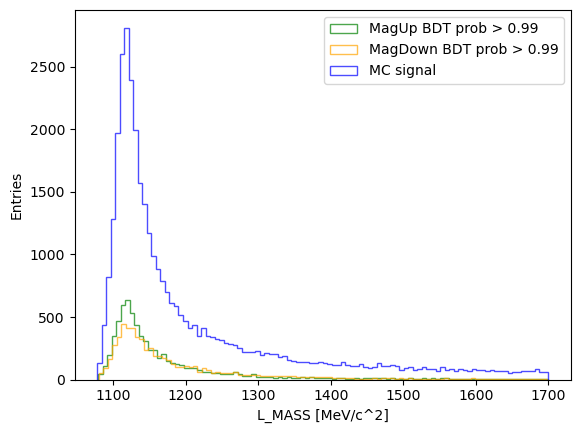

In [13]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = 100

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup.query('(prob > 0.99)')['L_MASS'], bins=binning, label='MagUp BDT prob > 0.99', color='green', alpha=0.7, histtype='step')
hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.99)')['L_MASS'], bins=binning, label='MagDown BDT prob > 0.99', color='orange', alpha=0.7, histtype='step')
hist2, bins2, _ = axes.hist(mc_data.query('(Lb_BKGCAT ==0)')['L_MASS'], bins=binning, label='MC signal', color='blue', alpha=0.7, histtype='step')

# hist2, bins2, _ = axes.hist(data24_magdown.query('(prob > 0.98) & (L_MASS <1300)')['Lb_MASS'], bins=binning, label='MagDown BDT cut', color='green', alpha=0.7, histtype='step')

# # Calculate the bin centers for the error bars
# bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
# bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# # Plot error bars for the first histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='Binary Data',
#     drawstyle='steps-mid'
# )

# Plot error bars for the second histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )
# axes.errorbar(
#     bin_centers2,
#     hist2,
#     yerr=np.sqrt(hist2),
#     fmt='o',
#     color='orange',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )

# Set labels and legend
plt.xlabel('L_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


In [2]:
import pandas as pd

In [3]:
data24_magup = pd.read_pickle('data24_magup_200_all.pkl')
data24_magdown = pd.read_pickle('data24_magdown_50_all.pkl')
mc_data = pd.read_pickle('mc_data_all.pkl')

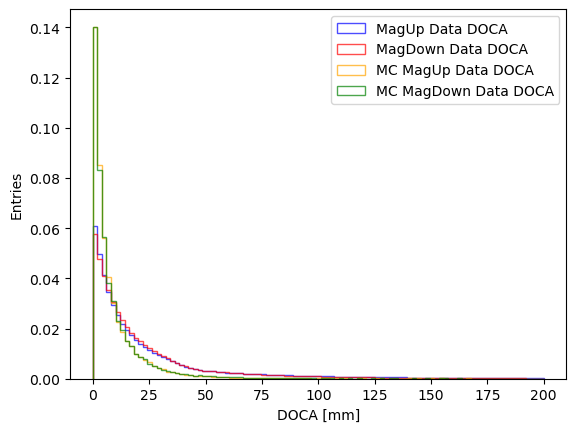

In [7]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = np.linspace(0, 200, 100)
density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup['DOCA'], bins=binning, label='MagUp Data DOCA', color='blue', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(data24_magdown['DOCA'], bins=binning, label='MagDown Data DOCA', color='red', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == True) & (Lb_BKGCAT == 0)')['DOCA'], bins=binning, label='MC MagUp Data DOCA', color='orange', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == False) & (Lb_BKGCAT == 0)')['DOCA'], bins=binning, label='MC MagDown Data DOCA', color='green', alpha=0.7, histtype='step',density= density)

# Set labels and legend
plt.xlabel('DOCA [mm]')
plt.ylabel('Entries') 
plt.legend()

# Display the plot
plt.show()


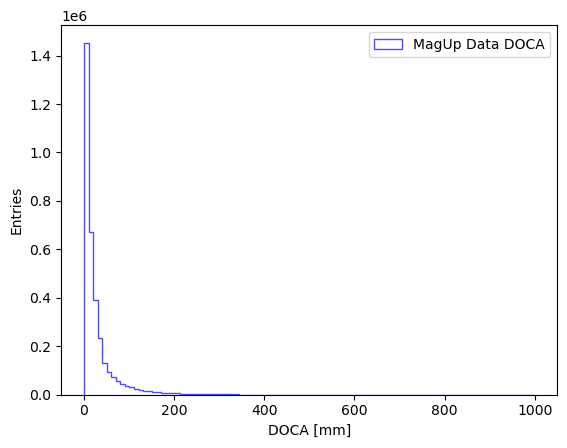

In [8]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = np.linspace(0, 1000, 100)
density = False

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup['DOCA'], bins=binning, label='MagUp Data DOCA', color='blue', alpha=0.7, histtype='step',density= density)
# hist1, bins1, _ = axes.hist(data24_magdown['DOCA'], bins=binning, label='MagDown Data DOCA', color='red', alpha=0.7, histtype='step',density= density)
# hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == True) & (Lb_BKGCAT == 0)')['DOCA'], bins=binning, label='MC MagUp Data DOCA', color='orange', alpha=0.7, histtype='step',density= density)
# hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == False) & (Lb_BKGCAT == 0)')['DOCA'], bins=binning, label='MC MagDown Data DOCA', color='green', alpha=0.7, histtype='step',density= density)

# Set labels and legend
plt.xlabel('DOCA [mm]')
plt.ylabel('Entries') 
plt.legend()

# Display the plot
plt.show()


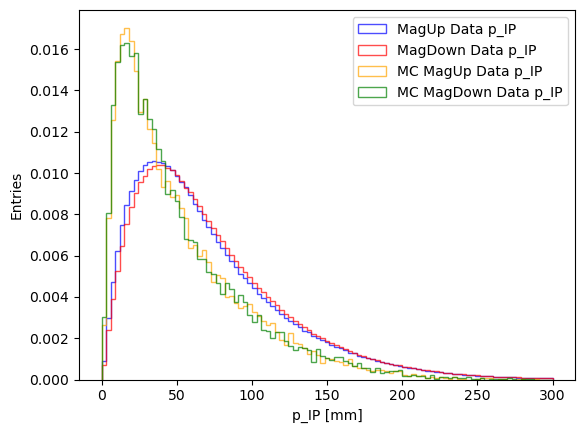

In [13]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = np.linspace(0, 300, 100)
density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup['p_RK_IP'], bins=binning, label='MagUp Data p_IP', color='blue', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(data24_magdown['p_RK_IP'], bins=binning, label='MagDown Data p_IP', color='red', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == True) & (Lb_BKGCAT == 0)')['p_RK_IP'], bins=binning, label='MC MagUp Data p_IP', color='orange', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == False) & (Lb_BKGCAT == 0)')['p_RK_IP'], bins=binning, label='MC MagDown Data p_IP', color='green', alpha=0.7, histtype='step',density= density)

# Set labels and legend
plt.xlabel('p_IP [mm]')
plt.ylabel('Entries') 
plt.legend()

# Display the plot
plt.show()


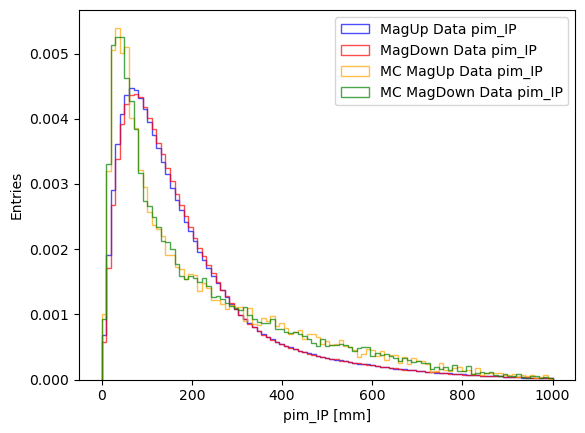

In [16]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = np.linspace(0, 1000, 100)
density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup['pim_RK_IP'], bins=binning, label='MagUp Data pim_IP', color='blue', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(data24_magdown['pim_RK_IP'], bins=binning, label='MagDown Data pim_IP', color='red', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == True) & (Lb_BKGCAT == 0)')['pim_RK_IP'], bins=binning, label='MC MagUp Data pim_IP', color='orange', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == False) & (Lb_BKGCAT == 0)')['pim_RK_IP'], bins=binning, label='MC MagDown Data pim_IP', color='green', alpha=0.7, histtype='step',density= density)

# Set labels and legend
plt.xlabel('pim_IP [mm]')
plt.ylabel('Entries') 
plt.legend()

# Display the plot
plt.show()


Checkeo de variables para el proton

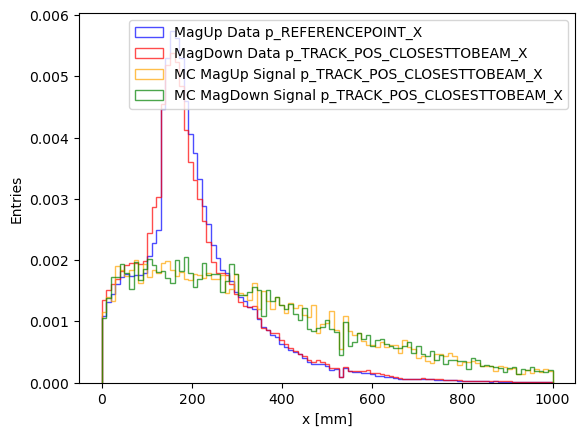

In [8]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = np.linspace(0, 1000, 100)
density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup['p_REFERENCEPOINT_X'], bins=binning, label='MagUp Data p_REFERENCEPOINT_X', color='blue', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(data24_magdown['p_TRACK_POS_CLOSESTTOBEAM_X'], bins=binning, label='MagDown Data p_TRACK_POS_CLOSESTTOBEAM_X', color='red', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == True) & (Lb_BKGCAT == 0)')['p_TRACK_POS_CLOSESTTOBEAM_X'], bins=binning, label='MC MagUp Signal p_TRACK_POS_CLOSESTTOBEAM_X', color='orange', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == False) & (Lb_BKGCAT == 0)')['p_TRACK_POS_CLOSESTTOBEAM_X'], bins=binning, label='MC MagDown Signal p_TRACK_POS_CLOSESTTOBEAM_X', color='green', alpha=0.7, histtype='step',density= density)

# Set labels and legend
plt.xlabel('x [mm]')
plt.ylabel('Entries') 
plt.legend()

# Display the plot
plt.show()


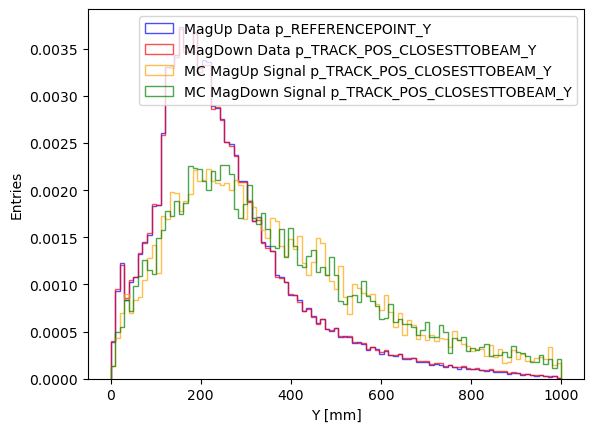

In [10]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = np.linspace(0, 1000, 100)
density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup['p_REFERENCEPOINT_Y'], bins=binning, label='MagUp Data p_REFERENCEPOINT_Y', color='blue', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(data24_magdown['p_TRACK_POS_CLOSESTTOBEAM_Y'], bins=binning, label='MagDown Data p_TRACK_POS_CLOSESTTOBEAM_Y', color='red', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == True) & (Lb_BKGCAT == 0)')['p_TRACK_POS_CLOSESTTOBEAM_Y'], bins=binning, label='MC MagUp Signal p_TRACK_POS_CLOSESTTOBEAM_Y', color='orange', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == False) & (Lb_BKGCAT == 0)')['p_TRACK_POS_CLOSESTTOBEAM_Y'], bins=binning, label='MC MagDown Signal p_TRACK_POS_CLOSESTTOBEAM_Y', color='green', alpha=0.7, histtype='step',density= density)

# Set labels and legend
plt.xlabel('Y [mm]')
plt.ylabel('Entries') 
plt.legend()

# Display the plot
plt.show()


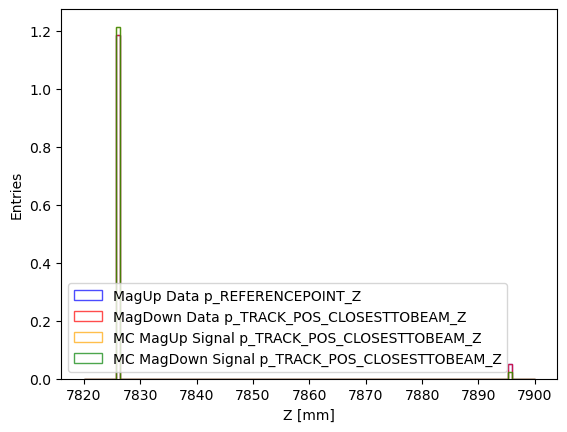

In [25]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = np.linspace(7820, 7900, 100)
density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup['p_REFERENCEPOINT_Z'], bins=binning, label='MagUp Data p_REFERENCEPOINT_Z', color='blue', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(data24_magdown['p_TRACK_POS_CLOSESTTOBEAM_Z'], bins=binning, label='MagDown Data p_TRACK_POS_CLOSESTTOBEAM_Z', color='red', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == True) & (Lb_BKGCAT == 0)')['p_TRACK_POS_CLOSESTTOBEAM_Z'], bins=binning, label='MC MagUp Signal p_TRACK_POS_CLOSESTTOBEAM_Z', color='orange', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == False) & (Lb_BKGCAT == 0)')['p_TRACK_POS_CLOSESTTOBEAM_Z'], bins=binning, label='MC MagDown Signal p_TRACK_POS_CLOSESTTOBEAM_Z', color='green', alpha=0.7, histtype='step',density= density)

# Set labels and legend
plt.xlabel('Z [mm]')
plt.ylabel('Entries') 
plt.legend()

# Display the plot
plt.show()


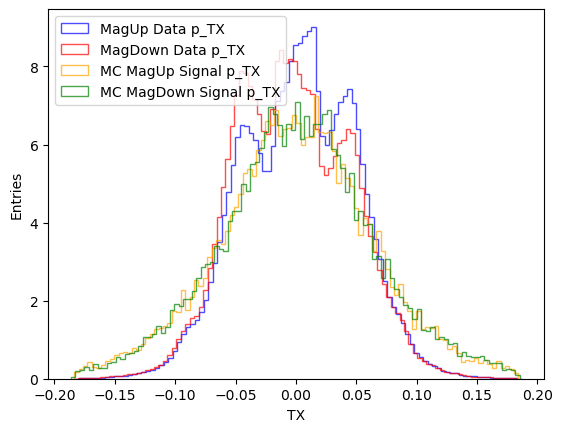

In [23]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = 100
density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup['p_TX'], bins=binning, label='MagUp Data p_TX', color='blue', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(data24_magdown['p_TX'], bins=binning, label='MagDown Data p_TX', color='red', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == True) & (Lb_BKGCAT == 0)')['p_TX'], bins=binning, label='MC MagUp Signal p_TX', color='orange', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == False) & (Lb_BKGCAT == 0)')['p_TX'], bins=binning, label='MC MagDown Signal p_TX', color='green', alpha=0.7, histtype='step',density= density)

# Set labels and legend
plt.xlabel('TX')
plt.ylabel('Entries') 
plt.legend()

# Display the plot
plt.show()


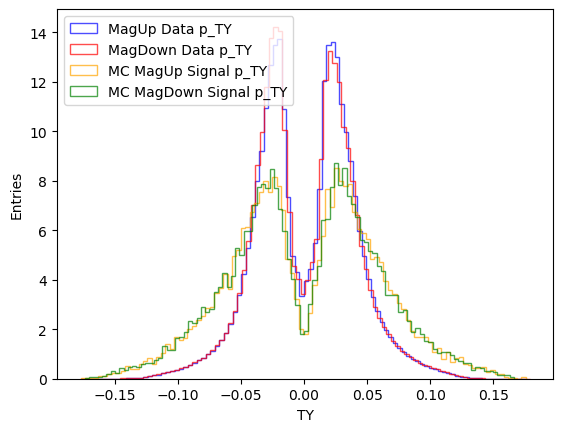

In [33]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = 100
density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup['p_TY'], bins=binning, label='MagUp Data p_TY', color='blue', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(data24_magdown['p_TY'], bins=binning, label='MagDown Data p_TY', color='red', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == True) & (Lb_BKGCAT == 0)')['p_TY'], bins=binning, label='MC MagUp Signal p_TY', color='orange', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == False) & (Lb_BKGCAT == 0)')['p_TY'], bins=binning, label='MC MagDown Signal p_TY', color='green', alpha=0.7, histtype='step',density= density)

# Set labels and legend
plt.xlabel('TY')
plt.ylabel('Entries') 
plt.legend()

# Display the plot
plt.show()


Para el pion 

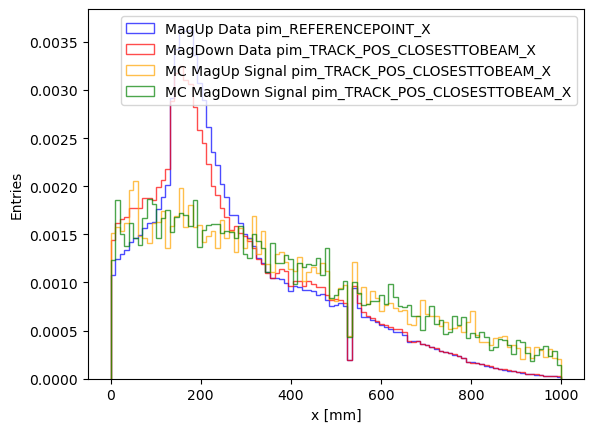

In [27]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = np.linspace(0, 1000, 100)
density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup['pim_REFERENCEPOINT_X'], bins=binning, label='MagUp Data pim_REFERENCEPOINT_X', color='blue', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(data24_magdown['pim_TRACK_POS_CLOSESTTOBEAM_X'], bins=binning, label='MagDown Data pim_TRACK_POS_CLOSESTTOBEAM_X', color='red', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == True) & (Lb_BKGCAT == 0)')['pim_TRACK_POS_CLOSESTTOBEAM_X'], bins=binning, label='MC MagUp Signal pim_TRACK_POS_CLOSESTTOBEAM_X', color='orange', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == False) & (Lb_BKGCAT == 0)')['pim_TRACK_POS_CLOSESTTOBEAM_X'], bins=binning, label='MC MagDown Signal pim_TRACK_POS_CLOSESTTOBEAM_X', color='green', alpha=0.7, histtype='step',density= density)

# Set labels and legend
plt.xlabel('x [mm]')
plt.ylabel('Entries') 
plt.legend()

# Display the plot
plt.show()


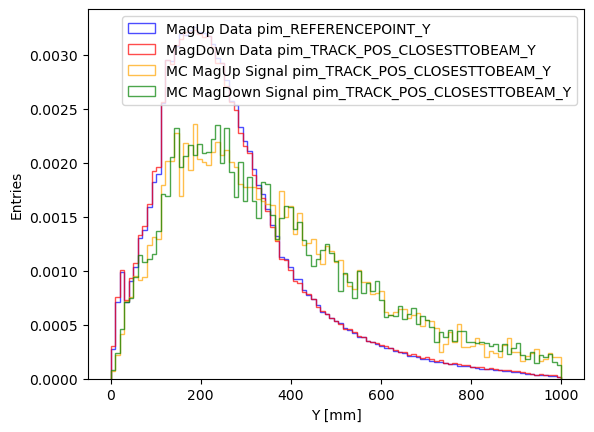

In [28]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = np.linspace(0, 1000, 100)
density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup['pim_REFERENCEPOINT_Y'], bins=binning, label='MagUp Data pim_REFERENCEPOINT_Y', color='blue', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(data24_magdown['pim_TRACK_POS_CLOSESTTOBEAM_Y'], bins=binning, label='MagDown Data pim_TRACK_POS_CLOSESTTOBEAM_Y', color='red', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == True) & (Lb_BKGCAT == 0)')['pim_TRACK_POS_CLOSESTTOBEAM_Y'], bins=binning, label='MC MagUp Signal pim_TRACK_POS_CLOSESTTOBEAM_Y', color='orange', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == False) & (Lb_BKGCAT == 0)')['pim_TRACK_POS_CLOSESTTOBEAM_Y'], bins=binning, label='MC MagDown Signal pim_TRACK_POS_CLOSESTTOBEAM_Y', color='green', alpha=0.7, histtype='step',density= density)

# Set labels and legend
plt.xlabel('Y [mm]')
plt.ylabel('Entries') 
plt.legend()

# Display the plot
plt.show()


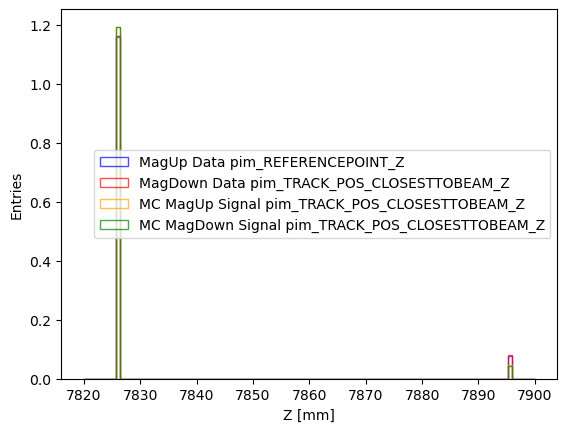

In [29]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = np.linspace(7820, 7900, 100)
density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup['pim_REFERENCEPOINT_Z'], bins=binning, label='MagUp Data pim_REFERENCEPOINT_Z', color='blue', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(data24_magdown['pim_TRACK_POS_CLOSESTTOBEAM_Z'], bins=binning, label='MagDown Data pim_TRACK_POS_CLOSESTTOBEAM_Z', color='red', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == True) & (Lb_BKGCAT == 0)')['pim_TRACK_POS_CLOSESTTOBEAM_Z'], bins=binning, label='MC MagUp Signal pim_TRACK_POS_CLOSESTTOBEAM_Z', color='orange', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == False) & (Lb_BKGCAT == 0)')['pim_TRACK_POS_CLOSESTTOBEAM_Z'], bins=binning, label='MC MagDown Signal pim_TRACK_POS_CLOSESTTOBEAM_Z', color='green', alpha=0.7, histtype='step',density= density)

# Set labels and legend
plt.xlabel('Z [mm]')
plt.ylabel('Entries') 
plt.legend()

# Display the plot
plt.show()


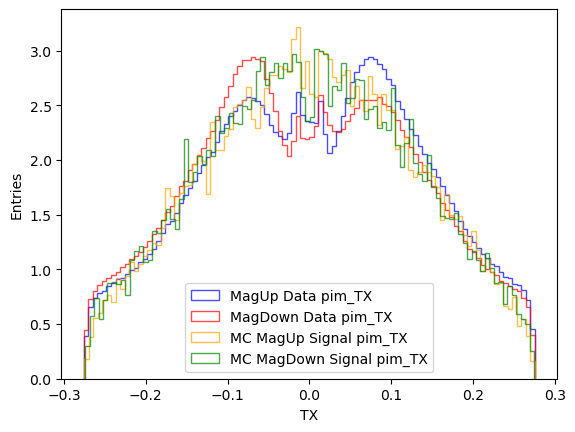

In [30]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = 100
density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup['pim_TX'], bins=binning, label='MagUp Data pim_TX', color='blue', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(data24_magdown['pim_TX'], bins=binning, label='MagDown Data pim_TX', color='red', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == True) & (Lb_BKGCAT == 0)')['pim_TX'], bins=binning, label='MC MagUp Signal pim_TX', color='orange', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == False) & (Lb_BKGCAT == 0)')['pim_TX'], bins=binning, label='MC MagDown Signal pim_TX', color='green', alpha=0.7, histtype='step',density= density)

# Set labels and legend
plt.xlabel('TX')
plt.ylabel('Entries') 
plt.legend()

# Display the plot
plt.show()


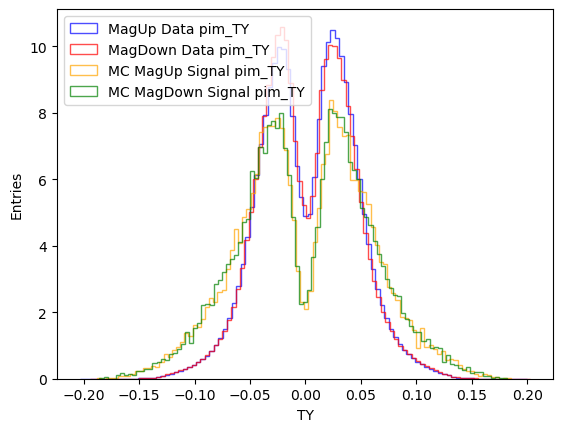

In [32]:
# Create the figure and axes
fig, axes = plt.subplots()
binning = 100
density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_magup['pim_TY'], bins=binning, label='MagUp Data pim_TY', color='blue', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(data24_magdown['pim_TY'], bins=binning, label='MagDown Data pim_TY', color='red', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == True) & (Lb_BKGCAT == 0)')['pim_TY'], bins=binning, label='MC MagUp Signal pim_TY', color='orange', alpha=0.7, histtype='step',density= density)
hist1, bins1, _ = axes.hist(mc_data.query('(MAGFIELD == False) & (Lb_BKGCAT == 0)')['pim_TY'], bins=binning, label='MC MagDown Signal pim_TY', color='green', alpha=0.7, histtype='step',density= density)

# Set labels and legend
plt.xlabel('TY')
plt.ylabel('Entries') 
plt.legend()

# Display the plot
plt.show()
